**Simple Conditional Workflow**

In [7]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END


In [4]:
#define the state
class QuadraticState(TypedDict):
    a: float
    b: float
    c: float
    d: float
    result: str

In [5]:
#define the nodes
def calculate_discriminant(state: QuadraticState):
    # Formula: d = b^2 - 4ac
    d = (state['b']**2) - (4 * state['a'] * state['c'])
    return {"d": d}

def handle_two_roots(state: QuadraticState):
    return {"result": f"The discriminant is {state['d']} (> 0). There are 2 real roots."}

def handle_one_root(state: QuadraticState):
    return {"result": f"The discriminant is 0. There is 1 repeated root."}

def handle_no_roots(state: QuadraticState):
    return {"result": f"The discriminant is {state['d']} (< 0). There are no real roots."}


In [8]:
#router funtion 

def route_based_on_discriminant(state: QuadraticState) -> Literal["two", "one", "none"]:
    d = state['d']
    if d > 0:
        return "two"
    elif d == 0:
        return "one"
    else:
        return "none"

In [9]:
builder = StateGraph(QuadraticState)

# Add Nodes
builder.add_node("calculate", calculate_discriminant)
builder.add_node("two_roots_node", handle_two_roots)
builder.add_node("one_root_node", handle_one_root)
builder.add_node("no_roots_node", handle_no_roots)

# Define flow
builder.add_edge(START, "calculate")

# Add the Conditional Logic
builder.add_conditional_edges(
    "calculate",                  # Start branching AFTER this node
    route_based_on_discriminant,  # The function that decides the path
    {                             # Mapping of return strings to node names
        "two": "two_roots_node",
        "one": "one_root_node",
        "none": "no_roots_node"
    }
)

# All paths end
builder.add_edge("two_roots_node", END)
builder.add_edge("one_root_node", END)
builder.add_edge("no_roots_node", END)

graph = builder.compile()

In [10]:
# Test 1: Two roots (x^2 - 5x + 6)
print(graph.invoke({"a": 1, "b": -5, "c": 6})["result"])

# Test 2: One root (x^2 - 4x + 4)
print(graph.invoke({"a": 1, "b": -4, "c": 4})["result"])

# Test 3: No real roots (x^2 + x + 1)
print(graph.invoke({"a": 1, "b": 1, "c": 1})["result"])

The discriminant is 1 (> 0). There are 2 real roots.
The discriminant is 0. There is 1 repeated root.
The discriminant is -3 (< 0). There are no real roots.


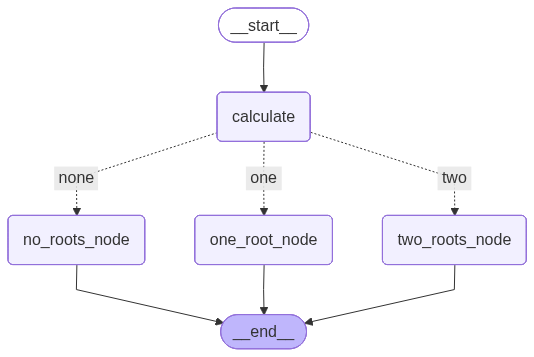

In [11]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())